# Rossmann Store Sales: Exploratory Analysis & Sales Prediction

Analysis of daily sales across 1,115 Rossmann stores, exploring what drives sales (holidays, promotions, competition, store type) and comparing two models for predicting future sales.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import seaborn as sb
import os

## 1. Combining store and sales data

Merge per-store metadata (`store.csv`) with daily sales records (`train.csv`) into a single dataframe.

In [11]:
trainData = pd.read_csv("train.csv", parse_dates=['Date'],low_memory=False)
storeData = pd.read_csv("store.csv")
df = trainData.merge(storeData,how = 'left',on ='Store')

In [13]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 2. Do people shop more during the holidays or before?

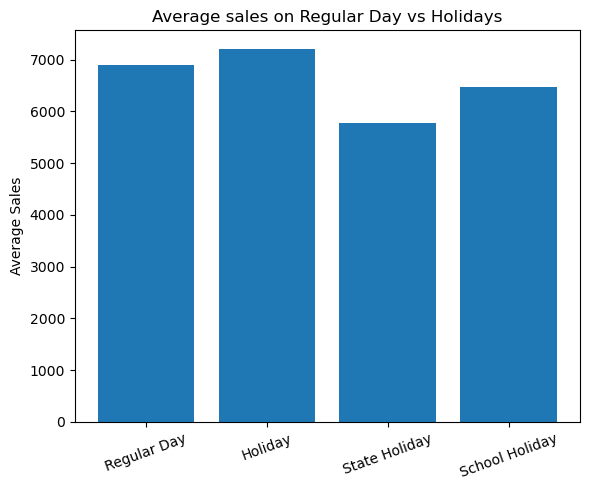

In [66]:
#check if its a holiday (state holidays have a,b,c to represent holidays else 0
df['isHoliday'] = ((df['StateHoliday']!='0')|(df['SchoolHoliday']==1)).astype(int)

#Average sales
df_open = df[df['Open']==1]
notHoliday_avg = df_open[df_open['isHoliday']==0]['Sales'].mean()
holiday_avg = df_open[df_open['isHoliday']==1]['Sales'].mean()
stateHoliday_avg = df[df['StateHoliday']!=0]['Sales'].mean()
schoolHoliday_avg = df[df['SchoolHoliday']==1]['Sales'].mean()

#Bar Chart
labels = ['Regular Day','Holiday','State Holiday','School Holiday']
values = [notHoliday_avg, holiday_avg, stateHoliday_avg, schoolHoliday_avg]

plt.figure(figsize=(6,5))
plt.bar(labels, values)
plt.title("Average sales on Regular Day vs Holidays")
plt.ylabel("Average Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


To answer this, I compared average sales on holidays vs. regular days. I first filtered to days when stores were open, then created a combined Holiday flag from state and school holidays before computing averages. Average sales are higher on holidays, suggesting people shop more around them. Sales are also higher on school holidays than state holidays, likely because stores stay open for school holidays but close for some state holidays.

## 3. Highest vs. lowest performing stores by cumulative sales

In [28]:
total_sales = df.groupby('Store')['Sales'].sum()
top5=total_sales.sort_values(ascending=False).head(5)
bottom5=total_sales.sort_values().head(5)

print(f"Stores with highest cumulative sales:\n",top5)
print(f"Stores with lowest cumulative sales:\n",bottom5)

Stores with highest cumulative sales:
 Store
262     19516842
817     17057867
562     16927322
1114    16202585
251     14896870
Name: Sales, dtype: int64
Stores with lowest cumulative sales:
 Store
307    2114322
543    2179287
198    2268273
208    2302052
263    2306075
Name: Sales, dtype: int64


**Assumption:** all stores in the dataset have at least 6 months of sales data, since the latest record (7/31/15) and earliest record (1/1/13) both include all 1,115 stores, suggesting no new stores were added during this period.

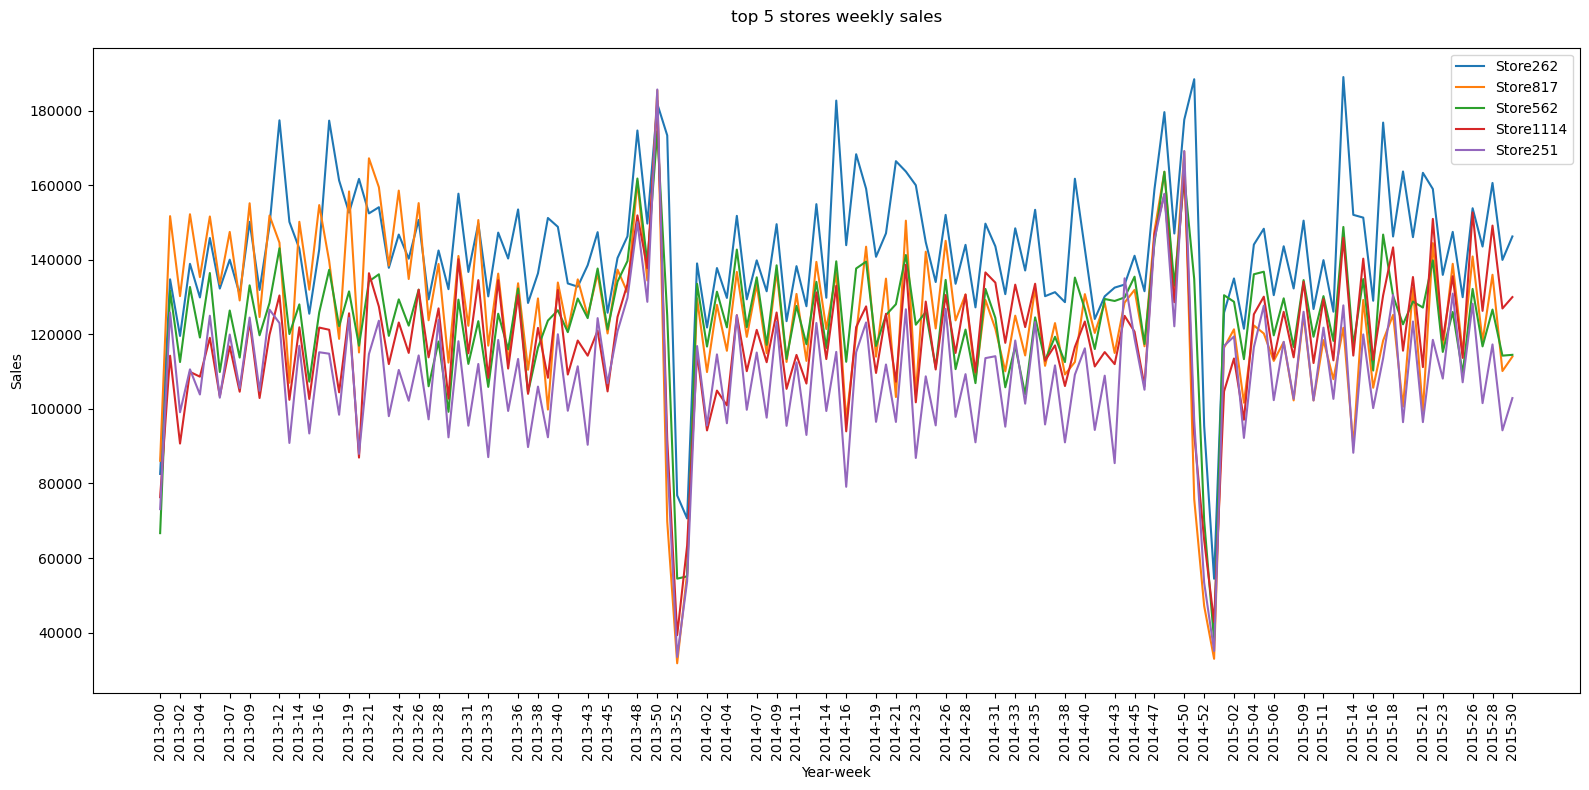

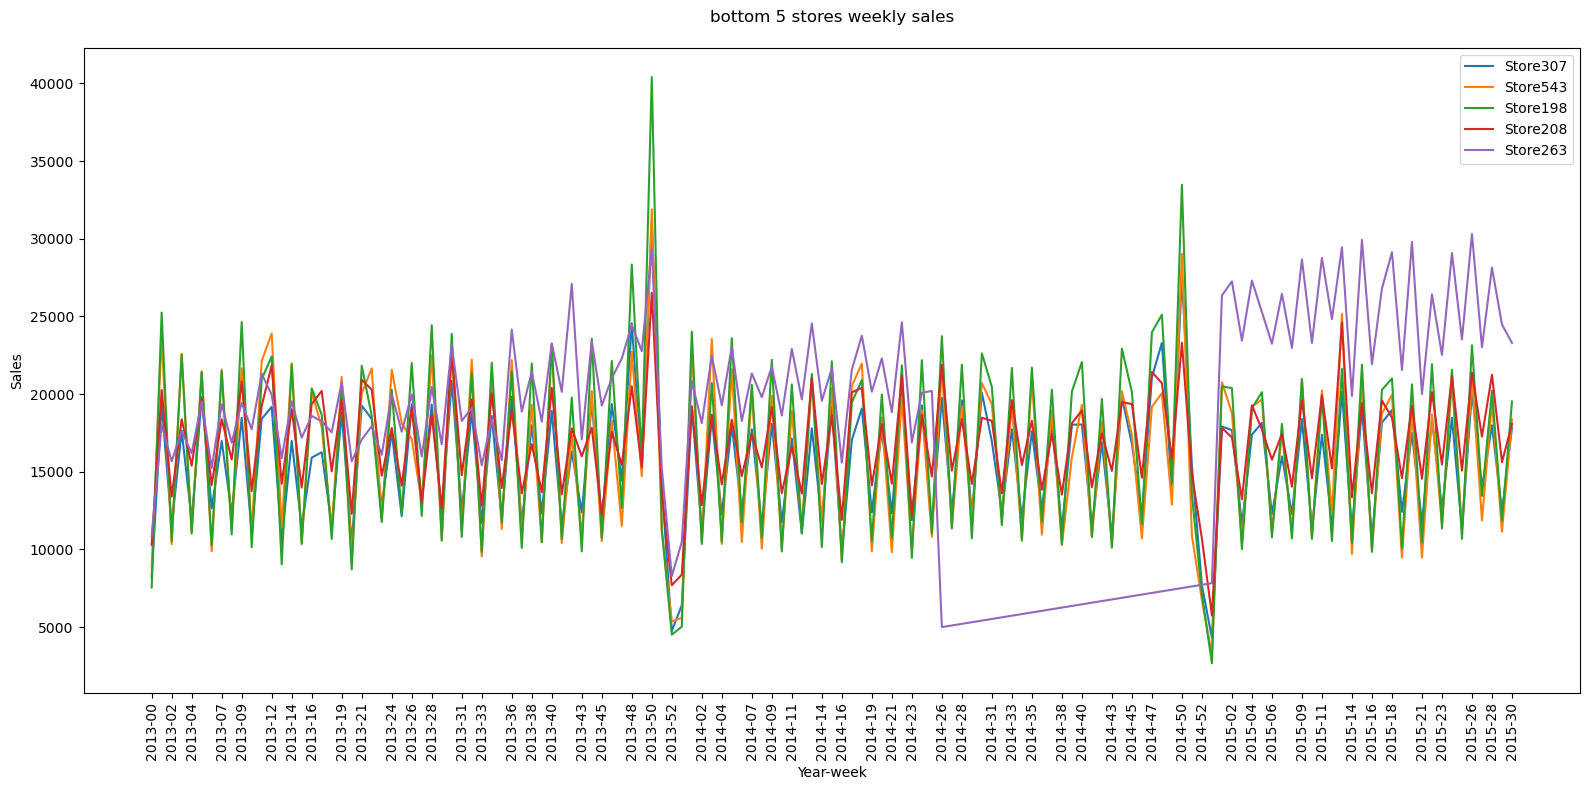

In [72]:
#convert date column to date type and identify weekly sales
df['Date'] = pd.to_datetime(df['Date'])
df['YearWeek']=df['Date'].dt.strftime('%Y-%U')
weekly_sales = df.groupby(['Store','YearWeek'])['Sales'].sum().reset_index()

#Top perfoming stores
top_stores = top5.index.tolist()
top_weekly=weekly_sales[weekly_sales['Store'].isin(top_stores)]
plt.figure(figsize=(16, 8))

for store in top_stores:
    store_data = top_weekly[top_weekly['Store']==store]
    plt.plot(store_data['YearWeek'], store_data['Sales'], label =f'Store{store}')

step = 12
plt.title('top 5 stores weekly sales\n')
plt.xticks(top_weekly['YearWeek'][::step],rotation=90)
plt.xlabel("Year-week")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

#Worst perfoming stores
bottom_stores = bottom5.index.tolist()
bottom_weekly = weekly_sales[weekly_sales['Store'].isin(bottom_stores)]
plt.figure(figsize=(16,8))

for store in bottom_stores:
    store_data=bottom_weekly[bottom_weekly['Store']==store]
    plt.plot(store_data['YearWeek'], store_data['Sales'], label=f'Store{store}')


plt.title("bottom 5 stores weekly sales\n")
plt.xticks(top_weekly['YearWeek'][::step],rotation=90)
plt.xlabel("Year-week")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


The better-performing stores show lower fluctuation in their sales, while the bottom five swing between very high and very low weeks despite operating in the same general sales range. The bottom five also perform similarly to each other, while the top performers are more distinguishable, with Store 262 the clear top performer.

## 4. Sales vs. distance to nearest competitor

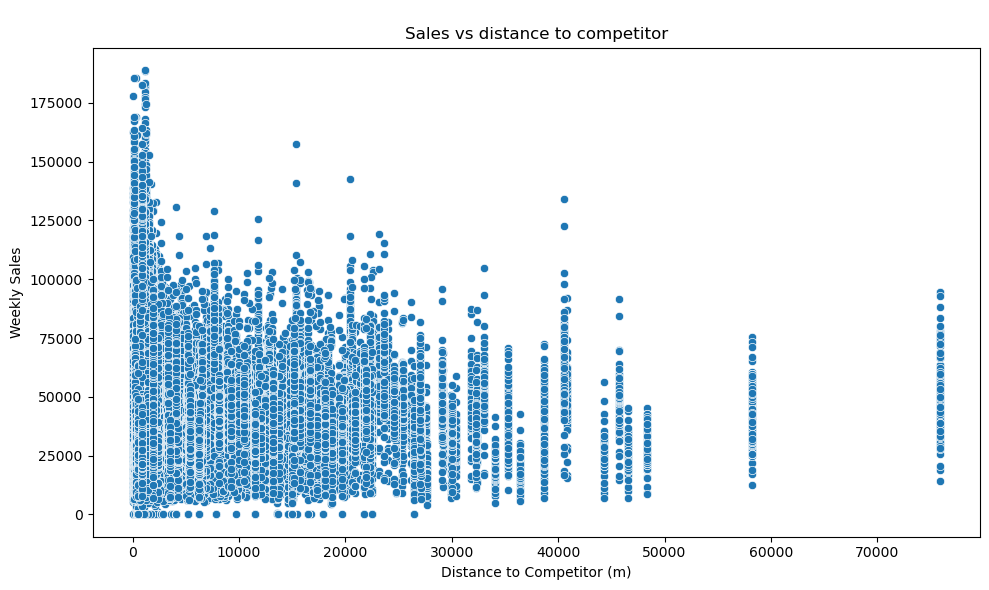

In [91]:
weekly_sales= df.groupby(['Store','YearWeek'],as_index = False)['Sales'].sum()
rival_distance = df[['Store','CompetitionDistance']].drop_duplicates()
weekly_sales = weekly_sales.merge(rival_distance, on='Store', how='left')
plt.figure(figsize=(10,6))
sb.scatterplot(data=weekly_sales, x='CompetitionDistance',y='Sales')

plt.title("\nSales vs distance to competitor")
plt.xlabel("Distance to Competitor (m)")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

The general trend suggests stores perform better the closer they are to a competitor, with the highest weekly sales found at distances under 5,000 meters before gradually decreasing.

## 5. Feature correlation: Pearson vs. Spearman


Pearson Correlation matrix: 
                         Sales  Customers  CompetitionDistance     Promo  \
Sales                1.000000   0.894572            -0.019229  0.452315   
Customers            0.894572   1.000000            -0.102861  0.316087   
CompetitionDistance -0.019229  -0.102861             1.000000  0.000138   
Promo                0.452315   0.316087             0.000138  1.000000   
DayOfWeek           -0.462078  -0.386365            -0.000025 -0.392925   

                     DayOfWeek  
Sales                -0.462078  
Customers            -0.386365  
CompetitionDistance  -0.000025  
Promo                -0.392925  
DayOfWeek             1.000000  


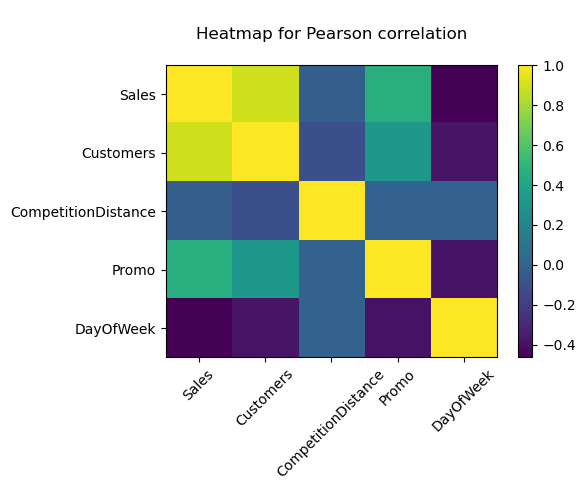


Spearman Correlation matrix: 
                         Sales  Customers  CompetitionDistance         Promo  \
Sales                1.000000   0.903008        -2.423468e-02  4.896796e-01   
Customers            0.903008   1.000000        -1.772956e-01  3.773212e-01   
CompetitionDistance -0.024235  -0.177296         1.000000e+00 -7.807418e-07   
Promo                0.489680   0.377321        -7.807418e-07  1.000000e+00   
DayOfWeek           -0.450591  -0.430773        -1.795446e-06 -3.927854e-01   

                     DayOfWeek  
Sales                -0.450591  
Customers            -0.430773  
CompetitionDistance  -0.000002  
Promo                -0.392785  
DayOfWeek             1.000000  


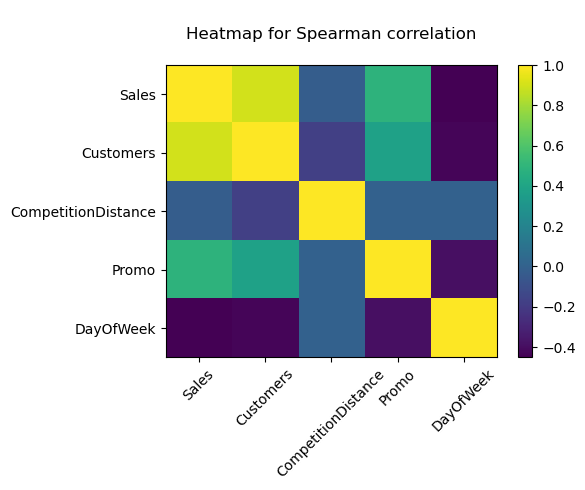

In [97]:
corr_features = ['Sales','Customers','CompetitionDistance','Promo','DayOfWeek']
corr_data = df[corr_features].copy().dropna()

#Pearson Correlation 
corr_pearson = corr_data.corr(method='pearson')
print("\nPearson Correlation matrix: \n",corr_pearson)
plt.figure(figsize=(6,5))
plt.imshow(corr_pearson.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_pearson.columns)), corr_pearson.columns, rotation =45)
plt.yticks(range(len(corr_pearson.index)), corr_pearson.index)
plt.title("\nHeatmap for Pearson correlation\n")
plt.tight_layout()
plt.show()

#spearman correlation
corr_spearman = corr_data.corr(method='spearman')
print("\nSpearman Correlation matrix: \n",corr_spearman)
plt.figure(figsize=(6,5))
plt.imshow(corr_spearman.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_pearson.columns)), corr_spearman.columns,rotation=45)
plt.yticks(range(len(corr_spearman.index)),corr_spearman.index)
plt.title("\nHeatmap for Spearman correlation\n")
plt.tight_layout()
plt.show()


## 6. Five informative plots

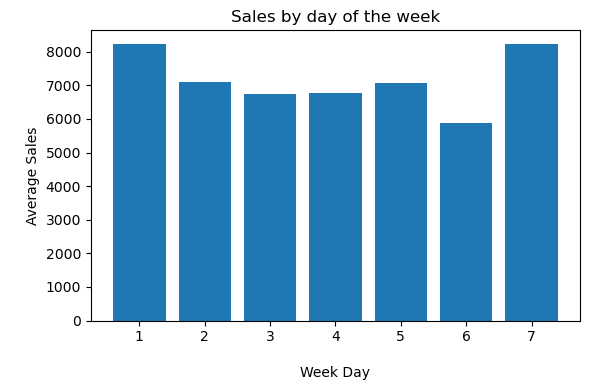

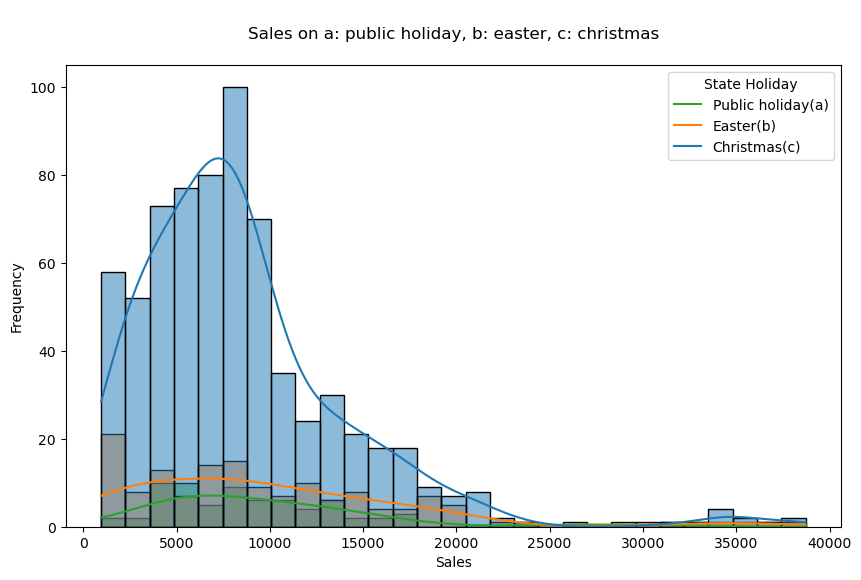

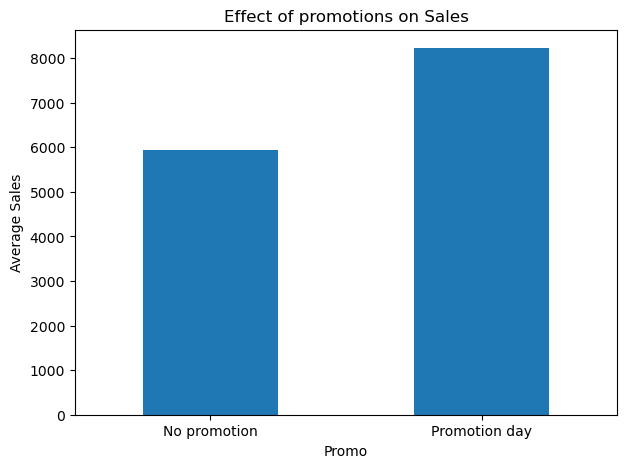

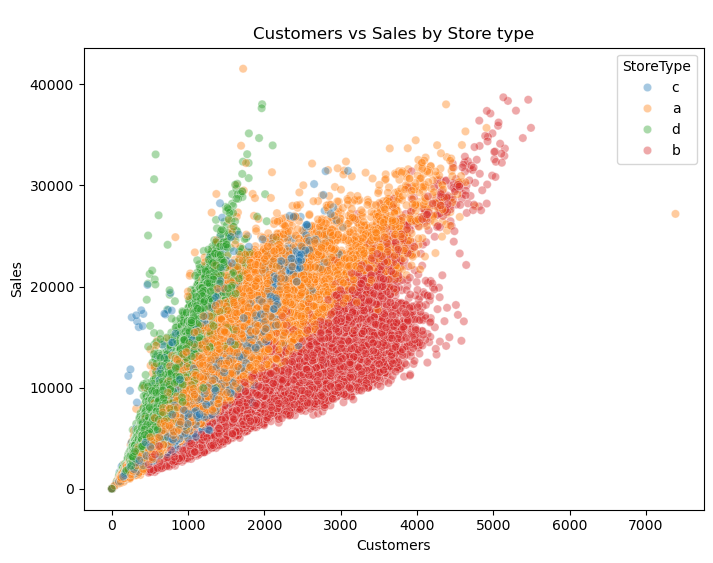

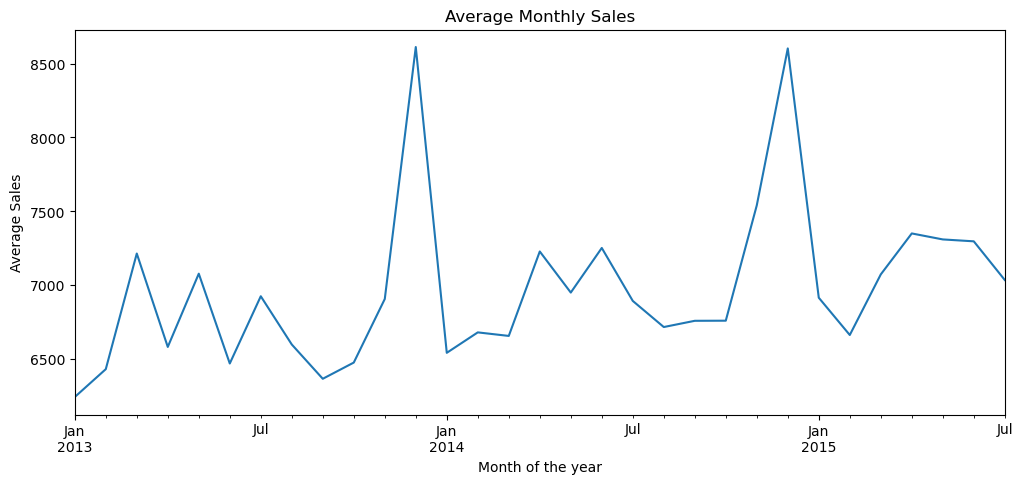

In [111]:
#Evaluate only when the stores are open and remove null values on sales and customers
df_open = df[df['Open']==1].dropna(subset=['Sales','Customers'])

#1. Average sales by day
daily_avg=df_open.groupby('DayOfWeek')['Sales'].mean().reindex([1,2,3,4,5,6,7]).reset_index()
plt.figure(figsize=(6,4))
plt.bar(daily_avg['DayOfWeek'].astype(str),daily_avg['Sales'])
plt.xlabel("\nWeek Day")
plt.ylabel("\nAverage Sales")
plt.title("Sales by day of the week")
plt.tight_layout()
plt.show()

#2. Sales on each state holiday (public holiday, easter and christmas)
state_holidays = df_open[df_open['StateHoliday'].isin(['a','b','c'])]
plt.figure(figsize=(10,6))
sb.histplot(data=state_holidays, x='Sales',hue='StateHoliday',kde=True)
plt.title("\nSales on a: public holiday, b: easter, c: christmas\n")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.legend(title="State Holiday", labels=['Public holiday(a)','Easter(b)','Christmas(c)'])
plt.show()

#3. Average Sales on Promo Days vs Without Promo
promo_avg = df_open.groupby('Promo')['Sales'].mean()
plt.figure(figsize=(7,5))
promo_avg.plot(kind='bar')
plt.xticks([0,1],['No promotion','Promotion day'], rotation=0)
plt.title("Effect of promotions on Sales")
plt.ylabel("Average Sales")
plt.show()

#4. Number of customers based on the store type (a,b,c,d)
plt.figure(figsize=(8,6))
sb.scatterplot(data=df_open, x='Customers', y='Sales',hue='StoreType',alpha=0.4)
plt.title("\nCustomers vs Sales by Store type")
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.show()

#5.Average sales by month of the year
df_open['Month']= df_open['Date'].dt.to_period('M')
monthly_sales = df_open.groupby('Month')['Sales'].mean()
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Average Monthly Sales")
plt.xlabel("Month of the year")
plt.ylabel("Average Sales")
plt.show()

Observations only consider days when stores were open:

1. Sales by day of week are highest on the weekend (days 1 and 7), which is expected since that's when most customers have the most free time to shop.
2. Sales are highest on Christmas, then Easter, then public holidays, likely due to festive-season shopping.
3. Promotions are clearly effective at boosting sales.
4. There's a strong correlation between customer count and sales. Store type D has the fewest customers but the highest sales per customer, while store type B has many customers but sales grow more gradually as customers increase, with types A and C falling in between.

## 7. Prediction models

In [119]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

pred_data = pd.read_csv('train.csv',parse_dates=['Date'],low_memory=False)
validation_mask = pred_data['Date'].dt.year ==2015
validation_mask &= pred_data['Date'].dt.month.isin([5,6,7])
validation_set = pred_data[validation_mask].copy()
train_set=pred_data[~validation_mask].copy()

#Replace null values in sales and customer with mean
for col in ['Sales','Customers']:
    avg = train_set[col].mean()
    train_set[col].fillna(avg, inplace=True)
    validation_set[col].fillna(avg, inplace=True)

#Drop any other missing values
train_set.dropna(inplace=True)
validation_set.dropna(inplace=True)

#One hot encode state holiday
train_set['StateHoliday']=train_set['StateHoliday'].replace({'a':1,'b':1,'c':1,0:0})
validation_set['StateHoliday']=validation_set['StateHoliday'].replace({'a':1,'b':1,'c':1,0:0})

features = ['Customers','Open','Promo','StateHoliday','SchoolHoliday','DayOfWeek']
X_train = train_set[features]
y_train = train_set['Sales']

X_val = validation_set[features]
Y_val = validation_set['Sales']

#Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
print("\nLinear Regression")
print("RMSE:",mean_squared_error(Y_val, y_pred_lr, squared=False))

#Model 2: Random forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)
print("\nRandom Forest:")
print("RMSE:",mean_squared_error(Y_val, y_pred_rf, squared=False))



/var/folders/wk/9sw16yz55hb812rr7v2_8vm00000gn/T/ipykernel_24167/3217423075.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_set[col].fillna(avg, inplace=True)
/var/folders/wk/9sw16yz55hb812rr7v2_8vm00000gn/T/ipykernel_24167/3217423075.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh


Linear Regression
RMSE: 1555.3194433707663


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



Random Forest:
RMSE: 1486.3061127081698


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


The Random Forest has a lower RMSE, meaning it performed slightly better than the Linear Regression model.

## 8. Statistical test of model performance

In [121]:
from scipy.stats import ttest_rel

t_stat = ttest_rel(y_pred_lr, y_pred_rf)
print("\nPaired t-test between Linear Regression and Random Forest:\n")
print("t-statistics:",t_stat)


Paired t-test between Linear Regression and Random Forest:

t-statistics: TtestResult(statistic=2.9890797823973334, pvalue=0.0027988534027028875, df=102579)


The t-statistic is approximately 3, indicating a noticeable difference between the two models' predictions, confirmed by the very low p-value (0.0028). Combined with the Random Forest's lower RMSE, this indicates it performs significantly better than the Linear Regression model, not just by chance.